In [1]:
import glob
import h5py
import importlib
import IPython.display as ipd
import numpy as np
import os
import sys
from pathlib import Path
import pickle
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

## Plot sparsity measure for each model 

Intuition comes from Vinje & Gallant 2000, where instead of comparing sparcity between non-classical and classical receptive fields, we will compare sparsity (a proxy for selectivity) between pre- and post-gain activations.

Sparsity here is measured as $S = \{1 - [\frac{(\sum r_i/n)^2}{\sum (r_i^2/n)}] \} / [1 - (1/n)] $, where $r_i$ was originally the trial-averaged respose at each time point, but here will be the stimuli averaged response of each unit in a given layer.
The delta in sparsity can then be measured as $S_{\text{shift}} = (S_{\text{post-gain}} - S_{\text{pre-gain}}) / (1 - S_{\text{pre-gain}} ) $




In [2]:
### Common helper functions 

def sparsity_stat(activations):
    n = activations.size
    sqr_mean = activations.mean() ** 2
    mean_sqr = (activations ** 2).mean()
    sparsity = (1 - (sqr_mean / mean_sqr)) / (1 - 1/n)

    # alt implementation
    # mean2 = activations.mean() ** 2
    # var = activations.var() 
    # sparsity2 = (1 - (mean2 / (mean2 + var)) ) / (1 - (1/n))

    return sparsity

def sparsity_shift(s_pre, s_post):
    shift = (s_post - s_pre) / (1 - s_pre)
    return shift 

def percent_change(s_pre, s_post):
    return (s_post - s_pre) / s_pre

def minmax_norm(x, axis=0):
    return (x - x.min(axis=axis, keepdims=True)) / (x.max(axis=axis, keepdims=True) - x.min(axis=axis, keepdims=True))

def unit_norm(x, axis=0):
    return x / np.linalg.norm(x, axis=axis, keepdims=True)

In [3]:
analysis_dir = Path(f"binaural_unit_activation_analysis/")
all_models = list(analysis_dir.glob("*v10*"))
models_to_run = []

for path in all_models:
    if not path.is_dir():
        continue
    if 'main' in path.stem and not ('latest' in path.stem or 'rand' in path.stem):
        continue 
    if 'control' in path.stem:
        continue
    models_to_run.append(path)

def get_model_name(stem):
    if 'late_only' in stem:
        return 'Late-only'
    elif 'early_only' in stem:
        return 'Early-only'
    elif 'control' in stem:
        return 'Baseline CNN'
    elif 'arch' in stem:
        arch_n = stem.split('_')[-1]
        return f'Feature-gain alt v{arch_n}'
    elif 'rand' in stem:
        return 'Feature-gain random weights'
    elif "main" in stem:
        return 'Feature-gain main'

model_name_dict = {path.stem: get_model_name(path.stem) for path in models_to_run}


In [4]:
models_to_run

[PosixPath('binaural_unit_activation_analysis/word_task_early_only_v10'),
 PosixPath('binaural_unit_activation_analysis/word_task_late_only_v10'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_10'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_6'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_7'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_8'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_9'),
 PosixPath('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckp

[Errno 2] Unable to synchronously open file (unable to open file: name = 'binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_rand_weights/word_task_v10_main_feature_gain_config_rand_weights_model_activations_0dB_time_avg_diotic.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error in Feature-gain random weights


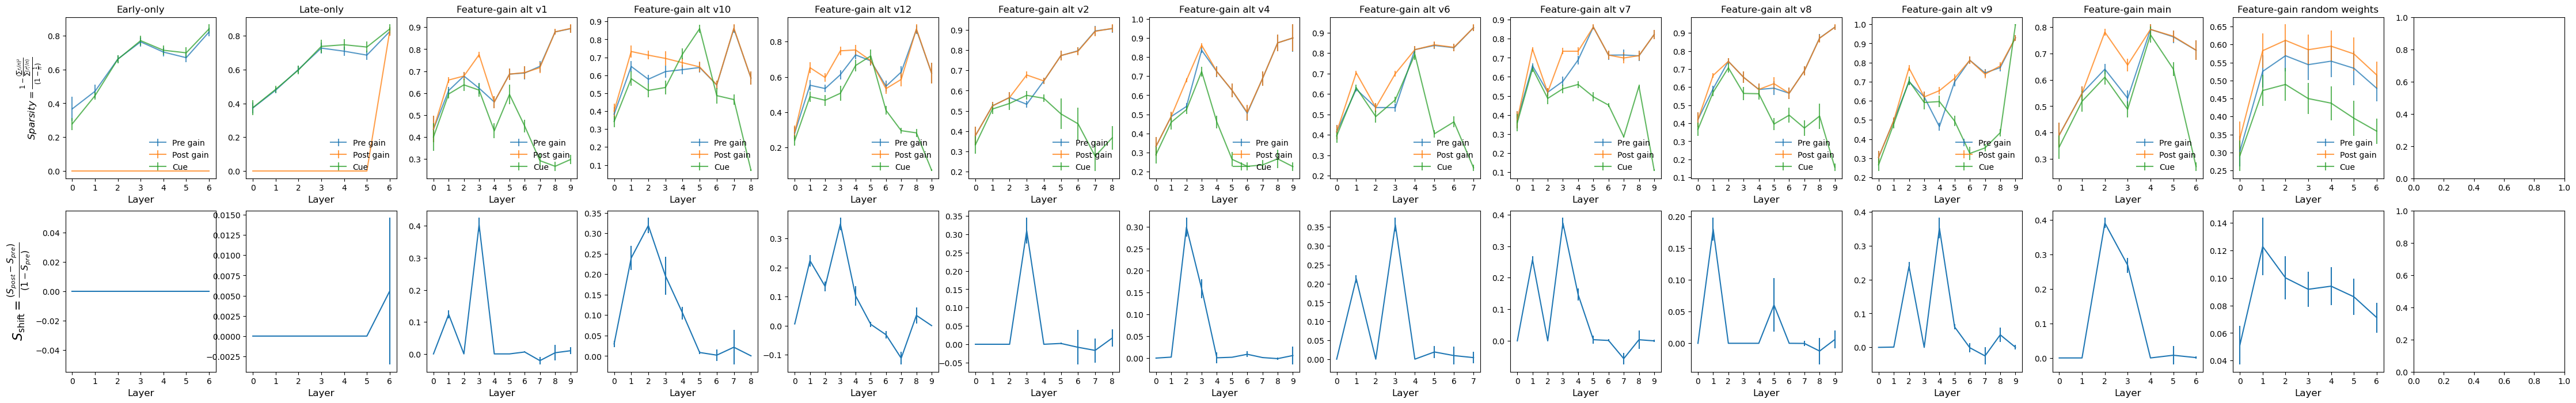

In [87]:
# model = "word_task_v10_main_feature_gain_config"

analysis_dir = Path(f"binaural_unit_activation_analysis/")
n_models = len(models_to_run)
fontsize = 12 
aspect = 4 
fig, axs = plt.subplots(2, n_models, figsize=(n_models * aspect, 2 * aspect))

dist_cond_list = ['same', 'diff',]# 'nat_scene']

for m_ix, model_dir in enumerate(models_to_run):
    h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
    model_name = model_name_dict[model_dir.stem]

    try:
        with h5py.File(h5_fn, 'r') as h5:
            n_layers = len([k for k in h5.keys() if 'relu' in k and 'target' in k and 'conv' in k and 'corr' not in k])
            x = np.arange(n_layers)
            sparsity_cue = np.zeros((n_layers, 2))
            sparsity_pre = np.zeros((n_layers, 2))
            sparsity_post = np.zeros((n_layers, 2))
            sparsity_shifts = np.zeros((n_layers, 2))
            sparsity_p_change = np.zeros((n_layers, 2))

            for layer_ix in range(n_layers):
                if layer_ix == n_layers-1:
                    gain_key = "attnfc"
                else:
                    gain_key = f"attn{layer_ix+1}"

                # filter dead units
                target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
                unit_total_act = target_acts.sum(0)
                good_unit_ixs = np.where(unit_total_act > 0)[0]

                mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0)
                n_examples = mixture_pre_attn.shape[0]
                trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
                
                post_gain_key = f"{gain_key}_mixture_same"
                if post_gain_key in h5.keys():
                    mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0) 
                    trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
                cue_key = f"hann_pool_{layer_ix}_cue_same"
                
                if cue_key in h5.keys():
                    cue_reps = h5[f"hann_pool_{layer_ix}_cue_same"][:][:, good_unit_ixs]
                    n_cue_egs = cue_reps.shape[0]
                else:
                    n_cue_egs = 0

                s_cue_list = np.zeros(n_cue_egs)
                s_pre_list = np.zeros(n_examples)
                s_post_list = np.zeros(n_examples)
                s_shift_list = np.zeros(n_examples)
                s_p_change_list = np.zeros(n_examples)

                for ix in range(n_examples):
                    if ix < n_cue_egs:
                        s_cue = sparsity_stat(cue_reps[ix])
                        s_cue_list[ix] = s_cue

                    s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                    s_pre_list[ix] = s_pre

                    if post_gain_key in h5.keys():
                        s_post = sparsity_stat(trial_mean_post_attn[ix])
                        s_shift = sparsity_shift(s_pre, s_post)
                        s_p_change = percent_change(s_pre, s_post)
                        s_post_list[ix] = s_post
                        s_shift_list[ix] = s_shift
                        s_p_change_list[ix] = s_p_change
                
                sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
                sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
                sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
                sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
                sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

            axs[0, m_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
            axs[0, m_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75)
            axs[0, m_ix].errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75)
            axs[0, m_ix].set_title(model_name, fontsize=fontsize)
            axs[0, m_ix].set_xlabel('Layer', fontsize=fontsize)
            axs[0, m_ix].set_xticks(x)

            if m_ix == 0:
                axs[0, m_ix].set_ylabel(r'$Sparsity = \frac{1 - \frac{(\sum{r_i / n})^2}{\sum (r_i^2 / n )}}{(1 - \frac{1}{n})}$', fontsize=fontsize)
            axs[0, m_ix].legend(loc='lower right', frameon=False)

            axs[1, m_ix].errorbar(x, sparsity_shifts[:, 0], yerr=sparsity_shifts[:, 1])
            # axs[1, m_ix].set_title("Shift in sparsity", fontsize=fontsize)
            axs[1, m_ix].set_xlabel('Layer', fontsize=fontsize)
            axs[1, m_ix].set_xticks(x)
            if m_ix == 0:
                axs[1, m_ix].set_ylabel(r'$S_{\text{shift}} = \frac{(S_{post} - S_{pre})}{(1 - S_{pre})}$', fontsize=fontsize+4)
    except Exception as e:
        print(e)
        print(f"Error in {model_name}")
        continue

[Errno 2] Unable to synchronously open file (unable to open file: name = 'binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_rand_weights/word_task_v10_main_feature_gain_config_rand_weights_model_activations_0dB_time_avg_diotic.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Error in Feature-gain random weights


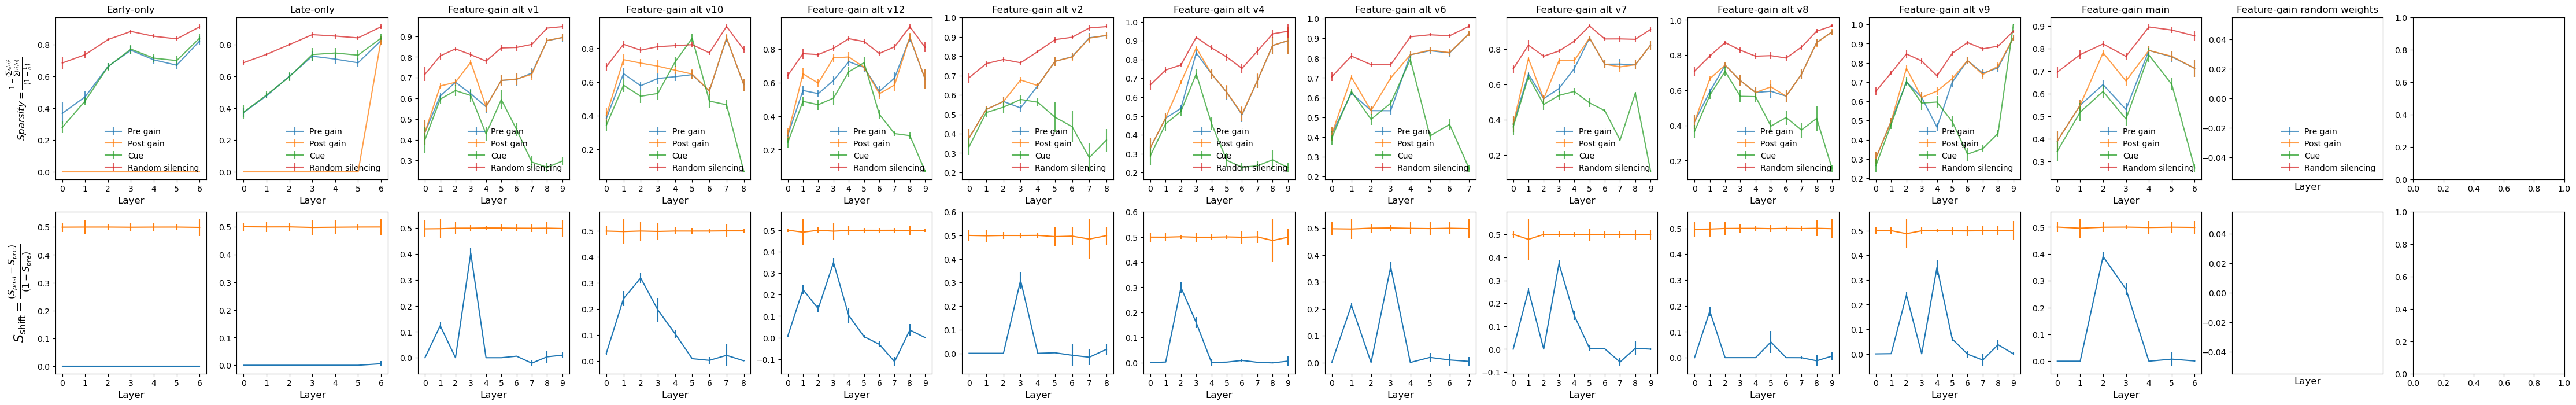

In [14]:
# model = "word_task_v10_main_feature_gain_config"

analysis_dir = Path(f"binaural_unit_activation_analysis/")
n_models = len(models_to_run)
fontsize = 12 
aspect = 4 
fig, axs = plt.subplots(2, n_models, figsize=(n_models * aspect, 2 * aspect))

dist_cond_list = ['same', 'diff',]# 'nat_scene']

for m_ix, model_dir in enumerate(models_to_run):
    h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
    model_name = model_name_dict[model_dir.stem]

    try:
        with h5py.File(h5_fn, 'r') as h5:
            n_layers = len([k for k in h5.keys() if 'relu' in k and 'target' in k and 'conv' in k and 'corr' not in k])
            x = np.arange(n_layers)
            sparsity_cue = np.zeros((n_layers, 2))
            sparsity_pre = np.zeros((n_layers, 2))
            sparsity_rand_sil = np.zeros((n_layers, 2))
            sparsity_post = np.zeros((n_layers, 2))
            sparsity_shifts = np.zeros((n_layers, 2))
            sparsity_rand_shifts = np.zeros((n_layers, 2))
            sparsity_p_change = np.zeros((n_layers, 2))

            for layer_ix in range(n_layers):
                if layer_ix == n_layers-1:
                    gain_key = "attnfc"
                else:
                    gain_key = f"attn{layer_ix+1}"

                # filter dead units
                target_acts = h5[f"hann_pool_{layer_ix}_target"][:]
                unit_total_act = target_acts.sum(0)
                good_unit_ixs = np.where(unit_total_act > 0)[0]

                mixture_pre_attn = np.concatenate([h5[f"hann_pool_{layer_ix}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0)
                n_examples = mixture_pre_attn.shape[0]
                trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
                
                post_gain_key = f"{gain_key}_mixture_same"
                if post_gain_key in h5.keys():
                    mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0) 
                    trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
                cue_key = f"hann_pool_{layer_ix}_cue_same"
                
                if cue_key in h5.keys():
                    cue_reps = h5[f"hann_pool_{layer_ix}_cue_same"][:][:, good_unit_ixs]
                    n_cue_egs = cue_reps.shape[0]
                else:
                    n_cue_egs = 0

                s_cue_list = np.zeros(n_cue_egs)
                s_rand_list = np.zeros(n_examples)
                s_pre_list = np.zeros(n_examples)
                s_post_list = np.zeros(n_examples)
                s_rand_shift_list = np.zeros(n_examples)
                s_shift_list = np.zeros(n_examples)
                s_p_change_list = np.zeros(n_examples)

                for ix in range(n_examples):
                    if ix < n_cue_egs:
                        s_cue = sparsity_stat(cue_reps[ix])
                        s_cue_list[ix] = s_cue

                    s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                    s_pre_list[ix] = s_pre

                    rand_sil = trial_mean_pre_attn[ix].copy()
                    rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
                    rand_sil[rand_ixs] = 0
                    s_rand = sparsity_stat(rand_sil)
                    s_rand_shift = sparsity_shift(s_pre, s_rand)
                    s_rand_list[ix] = s_rand
                    s_rand_shift_list[ix] = s_rand_shift

                    if post_gain_key in h5.keys():
                        s_post = sparsity_stat(trial_mean_post_attn[ix])
                        s_post = sparsity_stat(trial_mean_post_attn[ix])
                        s_shift = sparsity_shift(s_pre, s_post)
                        s_p_change = percent_change(s_pre, s_post)
                        s_post_list[ix] = s_post
                        s_shift_list[ix] = s_shift
                        s_p_change_list[ix] = s_p_change
                
                sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
                sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
                sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
                sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()
                sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
                sparsity_rand_shifts[layer_ix] = s_rand_shift_list.mean(), s_rand_shift_list.std()
                sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

            axs[0, m_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
            axs[0, m_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75)
            axs[0, m_ix].errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75)
            axs[0, m_ix].errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75)
            axs[0, m_ix].set_title(model_name, fontsize=fontsize)
            axs[0, m_ix].set_xlabel('Layer', fontsize=fontsize)
            axs[0, m_ix].set_xticks(x)

            if m_ix == 0:
                axs[0, m_ix].set_ylabel(r'$Sparsity = \frac{1 - \frac{(\sum{r_i / n})^2}{\sum (r_i^2 / n )}}{(1 - \frac{1}{n})}$', fontsize=fontsize)
            axs[0, m_ix].legend(loc='lower right', frameon=False)

            axs[1, m_ix].errorbar(x, sparsity_shifts[:, 0], yerr=sparsity_shifts[:, 1], label='Post gain shift')
            axs[1, m_ix].errorbar(x, sparsity_rand_shifts[:, 0], yerr=sparsity_rand_shifts[:, 1], label='Random silencing shift')
            # axs[1, m_ix].set_title("Shift in sparsity", fontsize=fontsize)
            axs[1, m_ix].set_xlabel('Layer', fontsize=fontsize)
            axs[1, m_ix].set_xticks(x)
            if m_ix == 0:
                axs[1, m_ix].set_ylabel(r'$S_{\text{shift}} = \frac{(S_{post} - S_{pre})}{(1 - S_{pre})}$', fontsize=fontsize+4)
    except Exception as e:
        print(e)
        print(f"Error in {model_name}")
        continue

In [104]:
layers

['cochleagram',
 'conv_block_0_relu_target',
 'conv_block_1_relu_target',
 'conv_block_2_relu_target',
 'conv_block_3_relu_target',
 'conv_block_4_relu_target',
 'conv_block_5_relu_target',
 'conv_block_6_relu_target',
 'conv_block_7_relu_target',
 'conv_block_8_relu_target',
 'conv_block_9_relu_target']

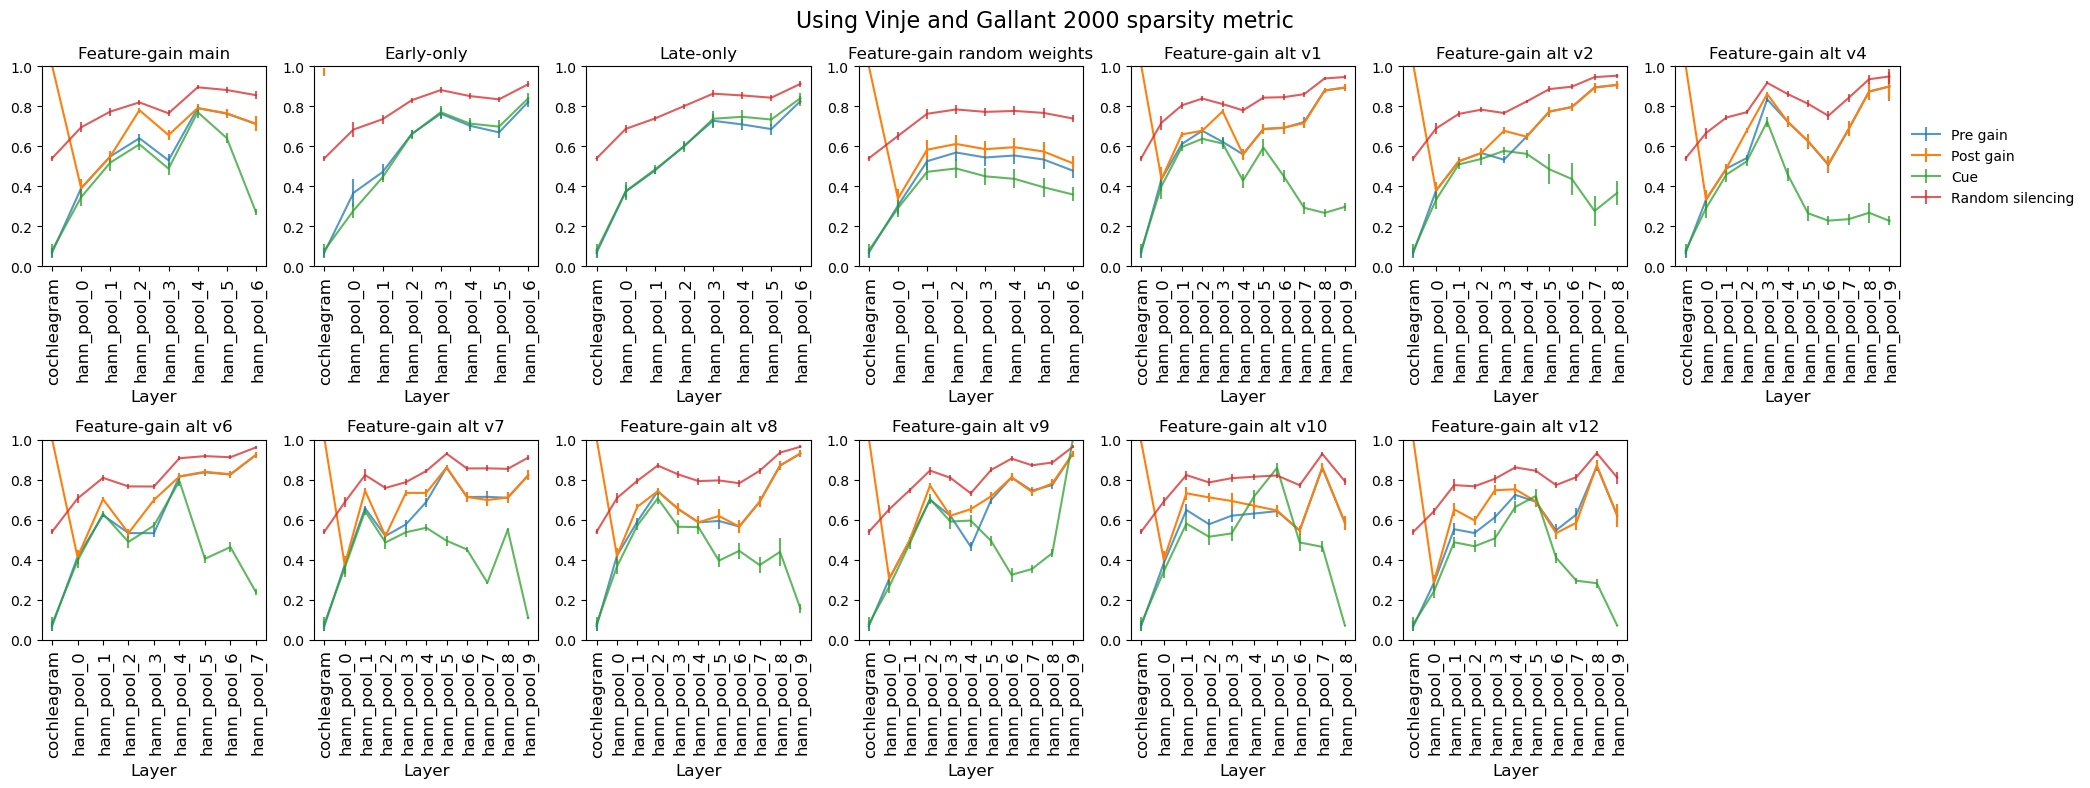

In [128]:
### Plot cleaned up version to share that has random silencing, 

# model = "word_task_v10_main_feature_gain_config"

models_to_run = [
 Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt'),
Path('binaural_unit_activation_analysis/word_task_early_only_v10'),
 Path('binaural_unit_activation_analysis/word_task_late_only_v10'),
 Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt_rand_weights'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_6'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_7'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_8'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_9'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_10'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12'),
]


analysis_dir = Path(f"binaural_unit_activation_analysis/")
n_models = len(models_to_run)
fontsize = 12 
aspect = 3

n_cols = 7
n_rows = 2 
fig, axs = plt.subplots(2, n_cols, figsize=(n_cols * aspect, n_rows * aspect + 2))
axs = axs.ravel()
dist_cond_list = ['same', 'diff',]# 'nat_scene']

for m_ix, model_dir in enumerate(models_to_run):
    h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
    model_name = model_name_dict[model_dir.stem]

    # try:
    with h5py.File(h5_fn, 'r') as h5:
        layers = ['cochleagram']
        layers += [k.split('_target')[0] for k in h5.keys() if 'pool' in k and 'target' in k and 'corr' not in k]
        n_layers = len(layers)
        x = np.arange(n_layers)
        sparsity_cue = np.zeros((n_layers, 2)) 
        sparsity_pre = np.zeros((n_layers, 2))
        sparsity_rand_sil = np.zeros((n_layers, 2))
        sparsity_post = np.zeros((n_layers, 2)) 
        # sparsity_shifts = np.zeros((n_layers, 2))
        # sparsity_rand_shifts = np.zeros((n_layers, 2))
        # sparsity_p_change = np.zeros((n_layers, 2))
        layer_names = []
        for layer_ix in range(n_layers):
            if layer_ix == n_layers-1:
                gain_key = "attnfc"
            else:
                gain_key = f"attn{layer_ix}"
            
            layer_str = 'cochleagram' if layer_ix == 0 else f"hann_pool_{layer_ix-1}"
            layer_names.append(layer_str)
            # filter dead units
            target_acts = h5[f"{layer_str}_target"][:]
            unit_total_act = target_acts.sum(0)
            good_unit_ixs = np.where(unit_total_act > 0)[0]

            mixture_pre_attn = np.concatenate([h5[f"{layer_str}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0)
            n_examples = mixture_pre_attn.shape[0]
            trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
            
            post_gain_key = f"{gain_key}_mixture_same"
            if post_gain_key in h5.keys():
                mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0) 
                trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
            cue_key = f"{layer_str}_cue_same" if layer_ix > 0 else f"cochleagram_cue"
            
            if cue_key in h5.keys():
                cue_reps = h5[cue_key][:][:, good_unit_ixs]
                n_cue_egs = cue_reps.shape[0]
            else:
                n_cue_egs = 0

            s_cue_list = np.zeros(n_cue_egs)
            s_rand_list = np.zeros(n_examples)
            s_pre_list = np.zeros(n_examples)
            s_post_list = np.zeros(n_examples)
            # s_rand_shift_list = np.zeros(n_examples)
            # s_shift_list = np.zeros(n_examples)
            # s_p_change_list = np.zeros(n_examples)

            for ix in range(n_examples):
                if ix < n_cue_egs:
                    s_cue = sparsity_stat(cue_reps[ix])
                    s_cue_list[ix] = s_cue

                s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                s_pre_list[ix] = s_pre

                rand_sil = trial_mean_pre_attn[ix].copy()
                rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
                rand_sil[rand_ixs] = 0
                s_rand = sparsity_stat(rand_sil)
                s_rand_shift = sparsity_shift(s_pre, s_rand)
                s_rand_list[ix] = s_rand
                # s_rand_shift_list[ix] = s_rand_shift

                if post_gain_key in h5.keys():
                    s_post = sparsity_stat(trial_mean_post_attn[ix])
                    s_shift = sparsity_shift(s_pre, s_post)
                    s_p_change = percent_change(s_pre, s_post)
                    s_post_list[ix] = s_post
                    # s_shift_list[ix] = s_shift
                    # s_p_change_list[ix] = s_p_change
            
            sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
            sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
            sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
            sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()
            # sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
            # sparsity_rand_shifts[layer_ix] = s_rand_shift_list.mean(), s_rand_shift_list.std()
            # sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

        sparsity_post_means = sparsity_post[:,0] 
        # set 0 to nan for plotting
        sparsity_post_means[sparsity_post_means == 0 ] = np.nan
        axs[m_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
        axs[m_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=1)
        axs[m_ix].errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75)
        axs[m_ix].errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75)
        axs[m_ix].set_title(model_name, fontsize=fontsize)
        axs[m_ix].set_xlabel('Layer', fontsize=fontsize)
        axs[m_ix].set_xticks(x)
        axs[m_ix].set_xticklabels(layers, rotation=90, size=12, 
                           ha='right', va='center_baseline',  rotation_mode='anchor')
        axs[m_ix].set_ylim(0, 1)
        if m_ix != 6:
            axs[m_ix].legend().remove()
        else:
            axs[m_ix].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

axs[-1].axis('off')

handle, labels = axs[12].get_legend_handles_labels()
# axs[-1].axis('off')


plt.suptitle('Using Vinje and Gallant 2000 sparsity metric', fontsize=fontsize+4)

plt.tight_layout()
    # except Exception as e:
    #     print(e)
    #     print(f"Error in {model_name}")
    #     continue

## Plot at each layer as sanity check. 

This is different analysis - not looking at effect of gains, but now comparing sparsity of representation through network depth

In [39]:
# Define the desired order of layers
def sort_layers(layers):
    # Separate layers into categories
    coch_layers = ['cochleagram', 'norm_coch_rep']
    fc_layers = ['attnfc', 'relufc']
    n_blocks = len([layer for layer in layers if 'hann_pool' in layer])

    block_order = []
    for block_ix in range(n_blocks):
        block_order.append(f'attn{block_ix}')
        block_order.append(f'conv_block_{block_ix}_ln')
        block_order.append(f'conv_block_{block_ix}_relu')
        block_order.append(f'hann_pool_{block_ix}')

    # Combine all categories in the desired order
    return coch_layers + block_order + fc_layers

# Example usage
layers = ['conv_block_0_ln', 'attn0', 'hann_pool_0', 'conv_block_0_relu', 'cochleagram', 'norm_coch_rep', 'attnfc', 'relufc']

sorted_layers = sort_layers(layers)
print(sorted_layers)


['cochleagram', 'norm_coch_rep', 'attn0', 'conv_block_0_ln', 'conv_block_0_relu', 'hann_pool_0', 'attnfc', 'relufc']


/tmp/ipykernel_973678/735393570.py:64: RuntimeWarning: Mean of empty slice.
  sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


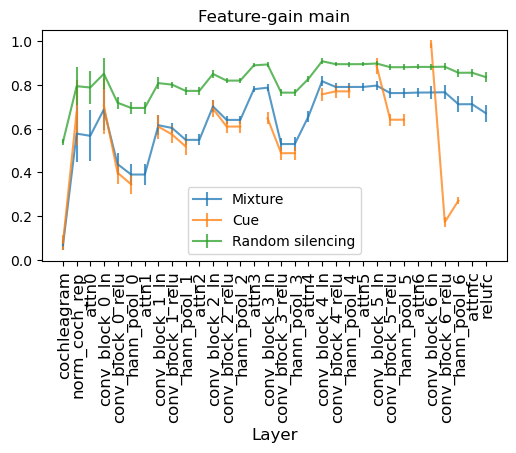

In [47]:
### Plot cleaned up version to share that has random silencing, 

# model = "word_task_v10_main_feature_gain_config"

model_dir = Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt')

fontsize = 12 
aspect = 3

fig, axs = plt.subplots(1, figsize=(2*aspect, aspect))
dist_cond_list = ['same', 'diff',]# 'nat_scene']

h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
model_name = model_name_dict[model_dir.stem]

# try:
with h5py.File(h5_fn, 'r') as h5:
    layers = [k.split('_target')[0] for k in h5.keys() if 'target' in k and 'corr' not in k and 'f0' not in k and 'location' not in k and 'word' not in k]
    layers = sort_layers(layers)
    n_layers = len(layers)
    x = np.arange(n_layers)
    sparsity_cue = np.zeros((n_layers, 2)) 
    sparsity_mixture = np.zeros((n_layers, 2))
    sparsity_rand_sil = np.zeros((n_layers, 2))

    for layer_ix, layer_str in enumerate(layers):
        # filter dead units
        target_acts = h5[f"{layer_str}_target"][:]
        unit_total_act = target_acts.sum(0)
        good_unit_ixs = np.where(unit_total_act > 0)[0]

        mixture_pre_attn = np.concatenate([h5[f"{layer_str}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0)
        n_examples = mixture_pre_attn.shape[0]
        trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
        
        cue_key = f"{layer_str}_cue_same" if layer_ix > 0 else f"cochleagram_cue"
        
        if cue_key in h5.keys():
            cue_reps = h5[cue_key][:][:, good_unit_ixs]
            n_cue_egs = cue_reps.shape[0]
        else:
            n_cue_egs = 0

        s_cue_list = np.zeros(n_cue_egs)
        s_rand_list = np.zeros(n_examples)
        s_pre_list = np.zeros(n_examples)
        s_post_list = np.zeros(n_examples)

        for ix in range(n_examples):
            if ix < n_cue_egs:
                s_cue = sparsity_stat(cue_reps[ix])
                s_cue_list[ix] = s_cue

            s_pre = sparsity_stat(trial_mean_pre_attn[ix])
            s_pre_list[ix] = s_pre

            rand_sil = trial_mean_pre_attn[ix].copy()
            rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
            rand_sil[rand_ixs] = 0
            s_rand = sparsity_stat(rand_sil)
            # s_rand_shift = sparsity_shift(s_pre, s_rand)
            s_rand_list[ix] = s_rand

        sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
        sparsity_mixture[layer_ix] = s_pre_list.mean(), s_pre_list.std()
        sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()

axs.errorbar(x, sparsity_mixture[:, 0], yerr=sparsity_mixture[:, 1], label='Mixture', alpha=0.75)
axs.errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75)
axs.errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75)
axs.set_title(model_name, fontsize=fontsize)
axs.set_xlabel('Layer', fontsize=fontsize)
axs.set_xticks(x)
axs.set_xticklabels(layers, rotation=90, size=12, 
                    ha='right', va='center_baseline',  rotation_mode='anchor');

axs.legend()

## Plot just different distractor types separately 
#### Plot just the activations to make the point

/tmp/ipykernel_973678/1153998690.py:70: RuntimeWarning: Mean of empty slice.
  sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/om2/user/imgriff/conda_envs/pytorch_2_sva/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


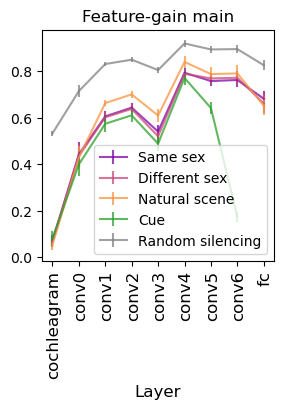

In [61]:
### Plot cleaned up version to share that has random silencing, 

# model = "word_task_v10_main_feature_gain_config"

model_dir = Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt')

fontsize = 12 
aspect = 3

fig, axs = plt.subplots(1, figsize=(aspect, aspect))
dist_cond_list = ['same', 'diff', 'nat_scene']
dist_cond_str = {'same': 'Same sex', 'diff': 'Different sex', 'nat_scene': 'Natural scene'}


h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
model_name = model_name_dict[model_dir.stem]

# try:
with h5py.File(h5_fn, 'r') as h5:
    layers = [k.split('_target')[0] for k in h5.keys() if 'target' in k and ('relu' in k or 'cochleagram' in k) and 'corr' not in k and 'f0' not in k and 'location' not in k and 'word' not in k]
    # layers = sort_layers(layers)
    layer_strs = [l.replace('_block_', '').replace('relu', '').strip('_') for l in layers]
    n_layers = len(layers)
    x = np.arange(n_layers)
    sparsity_cue = np.zeros((n_layers, 2)) 
    # sparsity_mixture = np.zeros((n_layers, 2))
    sparsity_rand_sil = np.zeros((n_layers, 2))
    dist_cond_sparsity = {cond: np.zeros((n_layers, 2)) for cond in dist_cond_list}


    for layer_ix, layer_str in enumerate(layers):
        # filter dead units
        target_acts = h5[f"{layer_str}_target"][:]
        unit_total_act = target_acts.sum(0)
        good_unit_ixs = np.where(unit_total_act > 0)[0]

        cue_key = f"{layer_str}_cue_same" if layer_ix > 0 else f"cochleagram_cue"
        
        if cue_key in h5.keys():
            cue_reps = h5[cue_key][:][:, good_unit_ixs]
            n_cue_egs = cue_reps.shape[0]
        else:
            n_cue_egs = 0

        for dist_cond in dist_cond_list:
            mixture_pre_attn = h5[f"{layer_str}_mixture_{dist_cond}"][:]
            n_examples = mixture_pre_attn.shape[0]
            trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
            
            s_cue_list = np.zeros(n_cue_egs)
            s_rand_list = np.zeros(n_examples)
            s_pre_list = np.zeros(n_examples)

            for ix in range(n_examples):
                if ix < n_cue_egs:
                    s_cue = sparsity_stat(cue_reps[ix])
                    s_cue_list[ix] = s_cue

                s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                s_pre_list[ix] = s_pre

                rand_sil = trial_mean_pre_attn[ix].copy()
                rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
                rand_sil[rand_ixs] = 0
                s_rand = sparsity_stat(rand_sil)
                # s_rand_shift = sparsity_shift(s_pre, s_rand)
                s_rand_list[ix] = s_rand

            if dist_cond == "same":
                sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
            dist_cond_sparsity[dist_cond][layer_ix] = s_pre_list.mean(), s_pre_list.std()
            sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()



dist_cond_hues = sns.color_palette('plasma', n_colors=len(dist_cond_list))
for dist_cond, hue in zip(dist_cond_list, dist_cond_hues):
    axs.errorbar(x, dist_cond_sparsity[dist_cond][:, 0], yerr=dist_cond_sparsity[dist_cond][:, 1], label=dist_cond_str[dist_cond], alpha=0.75, color=hue)
# axs.errorbar(x, sparsity_mixture[:, 0], yerr=sparsity_mixture[:, 1], label='Mixture', alpha=0.75)
axs.errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
axs.errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75, color='grey')
axs.set_title(model_name, fontsize=fontsize)
axs.set_xlabel('Layer', fontsize=fontsize)
axs.set_xticks(x)
axs.set_xticklabels(layer_strs, rotation=90, size=12, 
                    ha='right', va='center_baseline',  rotation_mode='anchor');

axs.legend()

#### Plot all architectures 


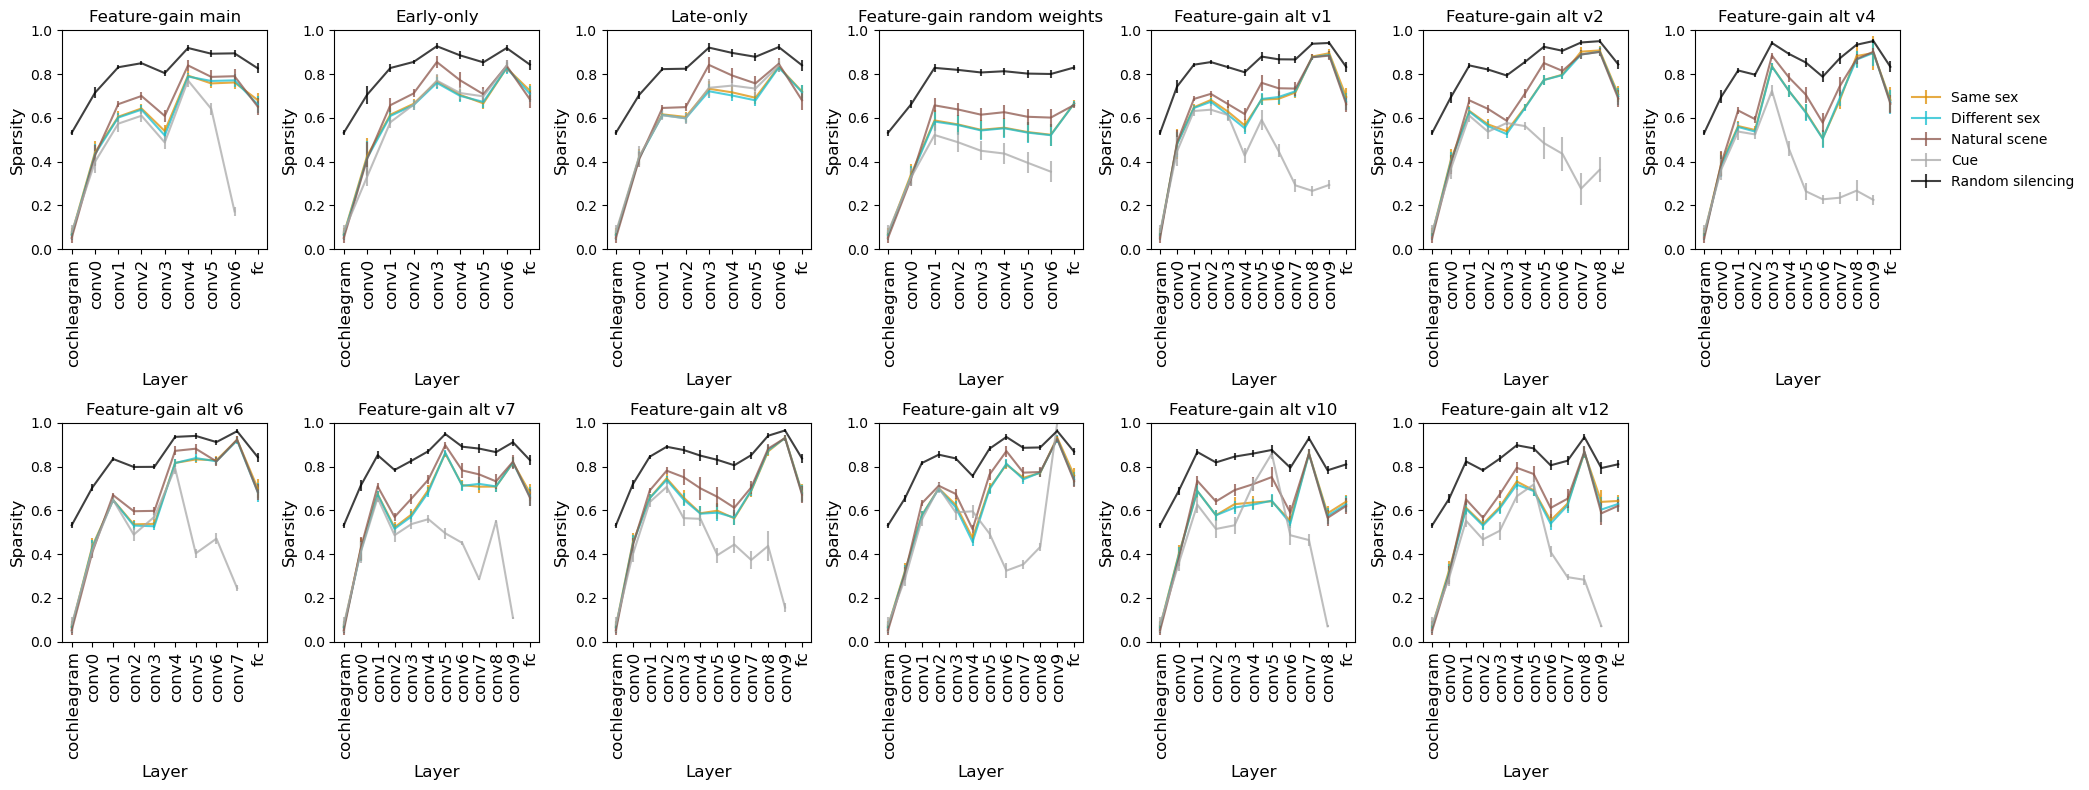

In [70]:
models_to_run = [
 Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt'),
 Path('binaural_unit_activation_analysis/word_task_early_only_v10'),
 Path('binaural_unit_activation_analysis/word_task_late_only_v10'),
 Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt_rand_weights'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_6'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_7'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_8'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_9'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_10'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12'),
]

n_models = len(models_to_run)
fontsize = 12 
aspect = 3

n_cols = 7
n_rows = 2 
fig, axs = plt.subplots(2, n_cols, figsize=(n_cols * aspect, n_rows * aspect + 2))
axs = axs.ravel()

dist_cond_list = ['same', 'diff', 'nat_scene']
dist_cond_str = {'same': 'Same sex', 'diff': 'Different sex', 'nat_scene': 'Natural scene'}
dist_cond_colors = {'same': 'blue', 'diff': '', 'nat_scene': 'Natural scene'}
hue_order = ['diff', 'same']

dist_cond_colors = dict(zip(hue_order, sns.color_palette(palette='colorblind', n_colors=10, as_cmap=False)))
dist_cond_colors['diff'] = 'tab:cyan'
dist_cond_colors['nat_scene'] = 'tab:brown'

for m_ix, model_dir in enumerate(models_to_run):
    h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
    model_name = model_name_dict[model_dir.stem]

    with h5py.File(h5_fn, 'r') as h5:
        layers = [k.split('_target')[0] for k in h5.keys() if 'target' in k and ('relu' in k or 'cochleagram' in k) and 'corr' not in k and 'f0' not in k and 'location' not in k and 'word' not in k]
        # layers = sort_layers(layers)
        layer_strs = [l.replace('_block_', '').replace('relu', '').strip('_') for l in layers]
        n_layers = len(layers)
        x = np.arange(n_layers)
        sparsity_cue = np.zeros((n_layers-1, 2)) # no cue at fully connected layer
        # sparsity_mixture = np.zeros((n_layers, 2))
        sparsity_rand_sil = np.zeros((n_layers, 2))
        dist_cond_sparsity = {cond: np.zeros((n_layers, 2)) for cond in dist_cond_list}


        for layer_ix, layer_str in enumerate(layers):
            # filter dead units
            target_acts = h5[f"{layer_str}_target"][:]
            unit_total_act = target_acts.sum(0)
            good_unit_ixs = np.where(unit_total_act > 0)[0]

            cue_key = f"{layer_str}_cue_same" if layer_ix > 0 else f"cochleagram_cue"
            
            if cue_key in h5.keys():
                cue_reps = h5[cue_key][:][:, good_unit_ixs]
                n_cue_egs = cue_reps.shape[0]
            else:
                n_cue_egs = 0

            for dist_cond in dist_cond_list:
                mixture_pre_attn = h5[f"{layer_str}_mixture_{dist_cond}"][:]
                n_examples = mixture_pre_attn.shape[0]
                trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
                
                s_cue_list = np.zeros(n_cue_egs)
                s_rand_list = np.zeros(n_examples)
                s_pre_list = np.zeros(n_examples)

                for ix in range(n_examples):
                    if ix < n_cue_egs:
                        s_cue = sparsity_stat(cue_reps[ix])
                        s_cue_list[ix] = s_cue

                    s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                    s_pre_list[ix] = s_pre

                    rand_sil = trial_mean_pre_attn[ix].copy()
                    rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
                    rand_sil[rand_ixs] = 0
                    s_rand = sparsity_stat(rand_sil)
                    # s_rand_shift = sparsity_shift(s_pre, s_rand)
                    s_rand_list[ix] = s_rand

                if dist_cond == "same" and n_cue_egs > 0:
                    sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
                dist_cond_sparsity[dist_cond][layer_ix] = s_pre_list.mean(), s_pre_list.std()
                sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()

    for dist_cond in dist_cond_list:
        axs[m_ix].errorbar(x, dist_cond_sparsity[dist_cond][:, 0], yerr=dist_cond_sparsity[dist_cond][:, 1], label=dist_cond_str[dist_cond], alpha=0.75, color=dist_cond_colors[dist_cond])
    axs[m_ix].errorbar(x[:-1], sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75, color='darkgrey')
    axs[m_ix].errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75, color='k')
    axs[m_ix].set_title(model_name, fontsize=fontsize)
    axs[m_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[m_ix].set_ylabel('Sparsity', fontsize=fontsize)
    axs[m_ix].set_xlabel('Layer', fontsize=fontsize)
    axs[m_ix].set_xticks(x)
    axs[m_ix].set_xticklabels(layer_strs, rotation=90, size=12, 
                        ha='right', va='center_baseline',  rotation_mode='anchor');
    axs[m_ix].set_ylim(0, 1)
    if m_ix != 6:
        axs[m_ix].legend().remove()
    else:
        axs[m_ix].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

axs[-1].axis('off')
plt.tight_layout()


## Plot using different sparsity metric

In [8]:

def sparsity_metric(x):
    """
    Computes the sparsity metric S(x) for a given vector x.
    
    Parameters:
    x (numpy array): Input vector
    
    Returns:
    float: Sparsity value in the range [0, 1]
    """
    x = np.asarray(x)
    if np.all(x == 0):  # Edge case for zero vector
        return 1.0
    
    l1_norm = np.linalg.norm(x, 1)
    l2_norm = np.linalg.norm(x, 2)
    n = len(x)
    
    sparsity = 1 - (l1_norm / l2_norm - 1) / (np.sqrt(n) - 1)
    return sparsity

# Example usage:
x1 = np.array([1, 1, 1, 1])  # Fully dense (Sparsity ~ 0)
x2 = np.array([1, 0, 0, 0])  # Maximally sparse (Sparsity ~ 1)
x3 = np.array([0.5, 0, 0.5, 0])  # Intermediate sparsity

print(sparsity_metric(x1))  # Should be close to 0
print(sparsity_metric(x2))  # Should be close to 1
print(sparsity_metric(x3))  # Should be in between


0.0
1.0
0.5857864376269051


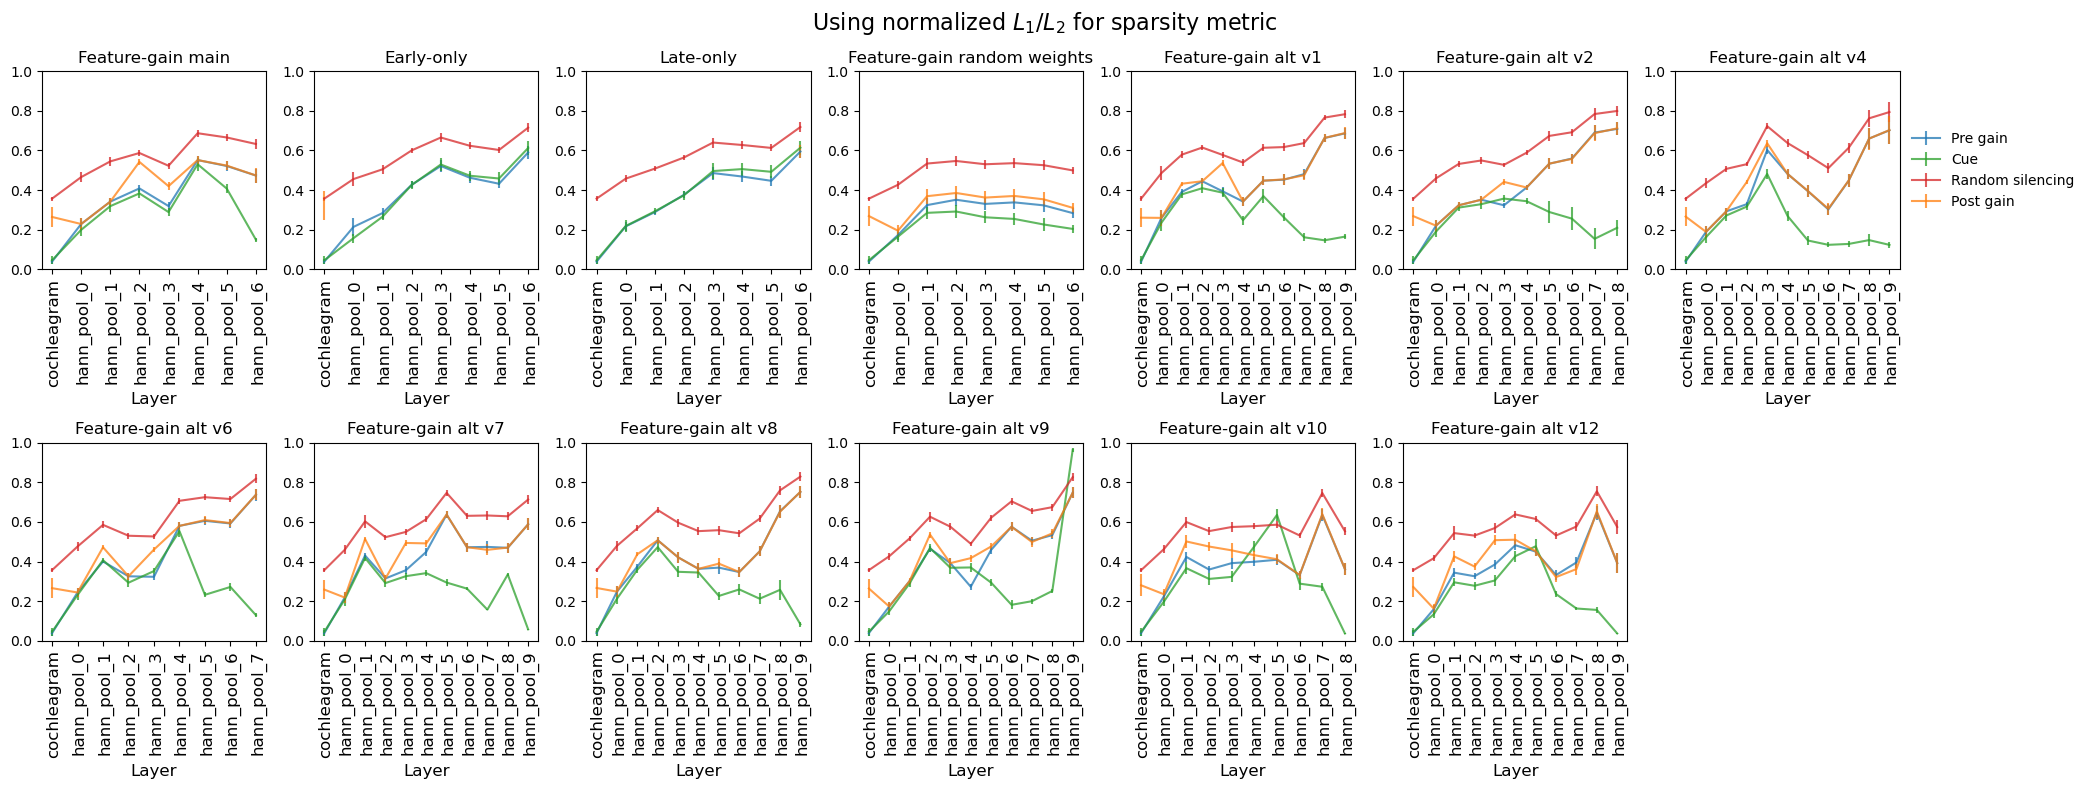

In [127]:
### Plot cleaned up version to share that has random silencing, 

# model = "word_task_v10_main_feature_gain_config"

analysis_dir = Path(f"binaural_unit_activation_analysis/")
n_models = len(models_to_run)
fontsize = 12 
aspect = 3

n_cols = 7
n_rows = 2 
fig, axs = plt.subplots(2, n_cols, figsize=(n_cols * aspect, n_rows * aspect + 2))
axs = axs.ravel()
dist_cond_list = ['same', 'diff',]# 'nat_scene']

for m_ix, model_dir in enumerate(models_to_run):
    h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
    model_name = model_name_dict[model_dir.stem]

    # try:
    with h5py.File(h5_fn, 'r') as h5:
        layers = ['cochleagram']
        layers += [k.split('_target')[0] for k in h5.keys() if 'pool' in k and 'target' in k and 'corr' not in k]
        n_layers = len(layers)
        x = np.arange(n_layers)
        sparsity_cue = np.zeros((n_layers, 2)) 
        sparsity_pre = np.zeros((n_layers, 2))
        sparsity_rand_sil = np.zeros((n_layers, 2))
        sparsity_post = np.zeros((n_layers, 2)) 
        # sparsity_shifts = np.zeros((n_layers, 2))
        # sparsity_rand_shifts = np.zeros((n_layers, 2))
        # sparsity_p_change = np.zeros((n_layers, 2))

        for layer_ix in range(n_layers):
            if layer_ix == n_layers-1:
                gain_key = "attnfc"
            else:
                gain_key = f"attn{layer_ix}"

            layer_str = 'cochleagram' if layer_ix == 0 else f"hann_pool_{layer_ix-1}"
            # filter dead units
            target_acts = h5[f"{layer_str}_target"][:]
            unit_total_act = target_acts.sum(0)
            good_unit_ixs = np.where(unit_total_act > 0)[0]

            mixture_pre_attn = np.concatenate([h5[f"{layer_str}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0)
            n_examples = mixture_pre_attn.shape[0]
            trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
            
            post_gain_key = f"{gain_key}_mixture_same"
            if post_gain_key in h5.keys():
                mixture_post_attn = np.concatenate([h5[f"{gain_key}_mixture_{sex_cond}"][:] for sex_cond in dist_cond_list], axis=0) 
                trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
            cue_key = f"{layer_str}_cue_same" if layer_ix > 0 else f"cochleagram_cue"
            
            if cue_key in h5.keys():
                cue_reps = h5[cue_key][:][:, good_unit_ixs]
                n_cue_egs = cue_reps.shape[0]
            else:
                n_cue_egs = 0

            s_cue_list = np.zeros(n_cue_egs)
            s_rand_list = np.zeros(n_examples)
            s_pre_list = np.zeros(n_examples)
            s_post_list = np.zeros(n_examples)
            # s_rand_shift_list = np.zeros(n_examples)
            # s_shift_list = np.zeros(n_examples)
            # s_p_change_list = np.zeros(n_examples)

            for ix in range(n_examples):
                if ix < n_cue_egs:
                    s_cue = sparsity_metric(cue_reps[ix])
                    s_cue_list[ix] = s_cue

                s_pre = sparsity_metric(trial_mean_pre_attn[ix])
                s_pre_list[ix] = s_pre

                rand_sil = trial_mean_pre_attn[ix].copy()
                rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
                rand_sil[rand_ixs] = 0
                s_rand = sparsity_metric(rand_sil)
                s_rand_shift = sparsity_shift(s_pre, s_rand)
                s_rand_list[ix] = s_rand
                # s_rand_shift_list[ix] = s_rand_shift

                if post_gain_key in h5.keys():
                    s_post = sparsity_metric(trial_mean_post_attn[ix])
                    s_shift = sparsity_shift(s_pre, s_post)
                    s_p_change = percent_change(s_pre, s_post)
                    s_post_list[ix] = s_post
                    # s_shift_list[ix] = s_shift
                    # s_p_change_list[ix] = s_p_change
            
            sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
            sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
            sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
            sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()
            # sparsity_shifts[layer_ix] = s_shift_list.mean(), s_shift_list.std()
            # sparsity_rand_shifts[layer_ix] = s_rand_shift_list.mean(), s_rand_shift_list.std()
            # sparsity_p_change[layer_ix] = s_p_change_list.mean(), s_p_change_list.std()

        sparsity_post_means = sparsity_post[:,0] 
        # set 0 to nan for plotting
        sparsity_post_means[sparsity_post_means == 0 ] = np.nan

        axs[m_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0])
        axs[m_ix].errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
        axs[m_ix].errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3])
        axs[m_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=0.75, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
        axs[m_ix].set_title(model_name, fontsize=fontsize)
        axs[m_ix].set_xlabel('Layer', fontsize=fontsize)
        axs[m_ix].set_xticks(x)
        axs[m_ix].set_xticklabels(layers, rotation=90, size=12, 
                    ha='right', va='center_baseline',  rotation_mode='anchor')
        axs[m_ix].set_ylim(0, 1)
        if m_ix != 6:
            axs[m_ix].legend().remove()
        else:
            axs[m_ix].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

axs[-1].axis('off')

plt.suptitle('Using normalized $L_1 / L_2$ for sparsity metric', fontsize=fontsize+4)
plt.tight_layout()
    # except Exception as e:
    #     print(e)
    #     print(f"Error in {model_name}")
    #     continue

## Plot distractor types separately

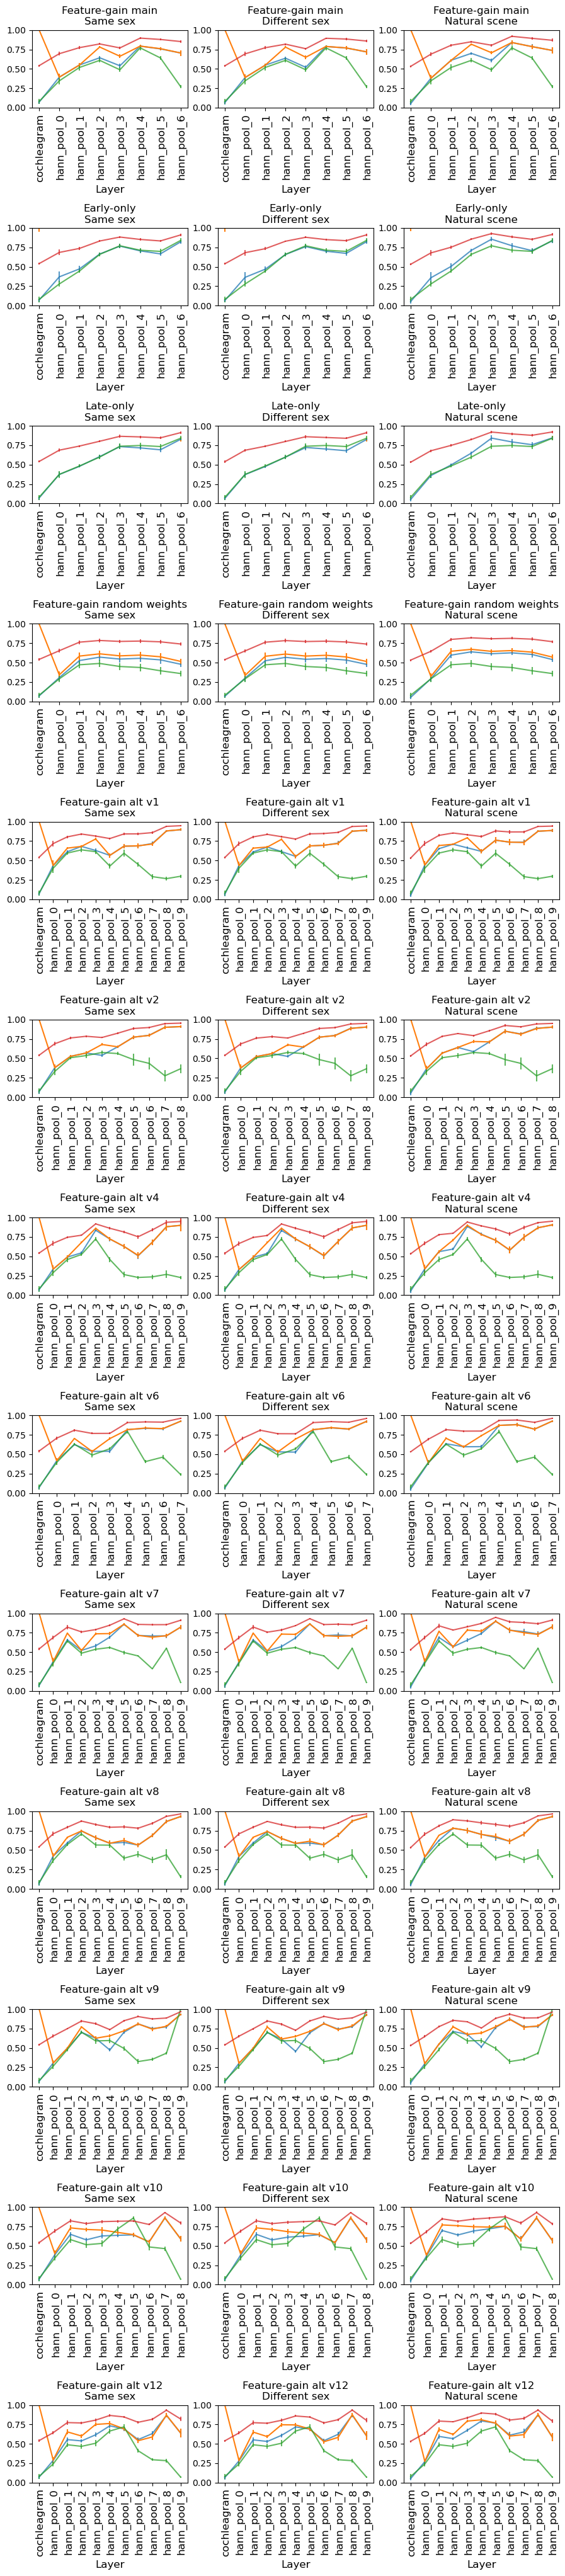

In [72]:
### Plot cleaned up version to share that has random silencing, 

# model = "word_task_v10_main_feature_gain_config"

models_to_run = [
 Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt'),
Path('binaural_unit_activation_analysis/word_task_early_only_v10'),
 Path('binaural_unit_activation_analysis/word_task_late_only_v10'),
 Path('binaural_unit_activation_analysis/word_task_v10_main_feature_gain_config_latest_ckpt_rand_weights'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_1'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_2'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_4'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_6'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_7'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_8'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_9'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_10'),
 Path('binaural_unit_activation_analysis/word_task_v10_4MGB_ln_first_arch_12'),
]


analysis_dir = Path(f"binaural_unit_activation_analysis/")
n_models = len(models_to_run)
fontsize = 12 
aspect = 3

n_cols = 3 # one per dist condition
n_rows = n_models # plot each model as a unique row 
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * aspect, n_rows * aspect + 2))

dist_cond_list = ['same', 'diff', 'nat_scene']
dist_cond_str = {'same': 'Same sex', 'diff': 'Different sex', 'nat_scene': 'Natural scene'}

for dist_ix, dist_cond in enumerate(dist_cond_list):
    for m_ix, model_dir in enumerate(models_to_run):
            h5_fn = model_dir / f"{model_dir.stem}_model_activations_0dB_time_avg_diotic.h5"
            model_name = model_name_dict[model_dir.stem]

            # try:
            with h5py.File(h5_fn, 'r') as h5:
                layers = ['cochleagram']
                layers += [k.split('_target')[0] for k in h5.keys() if 'pool' in k and 'target' in k and 'corr' not in k]
                n_layers = len(layers)
                x = np.arange(n_layers)
                sparsity_cue = np.zeros((n_layers, 2)) 
                sparsity_pre = np.zeros((n_layers, 2))
                sparsity_rand_sil = np.zeros((n_layers, 2))
                sparsity_post = np.zeros((n_layers, 2)) 
                # sparsity_shifts = np.zeros((n_layers, 2))
                # sparsity_rand_shifts = np.zeros((n_layers, 2))
                # sparsity_p_change = np.zeros((n_layers, 2))
                layer_names = []
                for layer_ix in range(n_layers):
                    if layer_ix == n_layers-1:
                        gain_key = "attnfc"
                    else:
                        gain_key = f"attn{layer_ix}"
                    
                    layer_str = 'cochleagram' if layer_ix == 0 else f"hann_pool_{layer_ix-1}"
                    layer_names.append(layer_str)
                    # filter dead units
                    target_acts = h5[f"{layer_str}_target"][:]
                    unit_total_act = target_acts.sum(0)
                    good_unit_ixs = np.where(unit_total_act > 0)[0]

                    mixture_pre_attn = h5[f"{layer_str}_mixture_{dist_cond}"][:]
                    n_examples = mixture_pre_attn.shape[0]
                    trial_mean_pre_attn = mixture_pre_attn[:, good_unit_ixs]
                    
                    post_gain_key = f"{gain_key}_mixture_same"
                    if post_gain_key in h5.keys():
                        mixture_post_attn = h5[f"{gain_key}_mixture_{dist_cond}"][:]
                        trial_mean_post_attn = mixture_post_attn[:, good_unit_ixs]
                    cue_key = f"{layer_str}_cue_same" if layer_ix > 0 else f"cochleagram_cue"
                    
                    if cue_key in h5.keys():
                        cue_reps = h5[cue_key][:][:, good_unit_ixs]
                        n_cue_egs = cue_reps.shape[0]
                    else:
                        n_cue_egs = 0

                    s_cue_list = np.zeros(n_cue_egs)
                    s_rand_list = np.zeros(n_examples)
                    s_pre_list = np.zeros(n_examples)
                    s_post_list = np.zeros(n_examples)

                    for ix in range(n_examples):
                        if ix < n_cue_egs:
                            s_cue = sparsity_stat(cue_reps[ix])
                            s_cue_list[ix] = s_cue

                        s_pre = sparsity_stat(trial_mean_pre_attn[ix])
                        s_pre_list[ix] = s_pre

                        rand_sil = trial_mean_pre_attn[ix].copy()
                        rand_ixs = np.random.choice(rand_sil.size, int(rand_sil.size * 0.5), replace=False)
                        rand_sil[rand_ixs] = 0
                        s_rand = sparsity_stat(rand_sil)
                        s_rand_shift = sparsity_shift(s_pre, s_rand)
                        s_rand_list[ix] = s_rand
                        # s_rand_shift_list[ix] = s_rand_shift

                        if post_gain_key in h5.keys():
                            s_post = sparsity_stat(trial_mean_post_attn[ix])
                            s_shift = sparsity_shift(s_pre, s_post)
                            s_p_change = percent_change(s_pre, s_post)
                            s_post_list[ix] = s_post
                            # s_shift_list[ix] = s_shift
                            # s_p_change_list[ix] = s_p_change
                    
                    sparsity_cue[layer_ix] = s_cue_list.mean(), s_cue_list.std()
                    sparsity_pre[layer_ix] = s_pre_list.mean(), s_pre_list.std()
                    sparsity_post[layer_ix] = s_post_list.mean(), s_post_list.std()
                    sparsity_rand_sil[layer_ix] = s_rand_list.mean(), s_rand_list.std()

                sparsity_post_means = sparsity_post[:,0] 
                # set 0 to nan for plotting
                sparsity_post_means[sparsity_post_means == 0 ] = np.nan
                axs[m_ix, dist_ix].errorbar(x, sparsity_pre[:, 0], yerr=sparsity_pre[:, 1], label='Pre gain', alpha=0.75)
                axs[m_ix, dist_ix].errorbar(x, sparsity_post[:, 0], yerr=sparsity_post[:, 1], label='Post gain', alpha=1)
                axs[m_ix, dist_ix].errorbar(x, sparsity_cue[:, 0], yerr=sparsity_cue[:, 1], label='Cue', alpha=0.75)
                axs[m_ix, dist_ix].errorbar(x, sparsity_rand_sil[:, 0], yerr=sparsity_rand_sil[:, 1], label='Random silencing', alpha=0.75)
                dist_str = dist_cond_str[dist_cond]
                axs[m_ix, dist_ix].set_title(f"{model_name}\n{dist_str}", fontsize=fontsize)
                axs[m_ix, dist_ix].set_xlabel('Layer', fontsize=fontsize)
                axs[m_ix, dist_ix].set_xticks(x)

                axs[m_ix, dist_ix].set_xticklabels(layers, rotation=90, size=12, 
                                ha='right', va='center_baseline',  rotation_mode='anchor')
                axs[m_ix, dist_ix].set_ylim(0, 1)
                # if m_ix != 6:
                axs[m_ix, dist_ix].legend().remove()
                # else:
                    # axs[m_ix, dist_ix].legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# axs[-1].axis('off')

# handle, labels = axs[12].get_legend_handles_labels()
# axs[-1].axis('off')


# plt.suptitle('Using Vinje and Gallant 2000 sparsity metric', fontsize=fontsize+4)

plt.tight_layout()
    # except Exception as e:
    #     print(e)
    #     print(f"Error in {model_name}")
    #     continue